# Set up

## Import packages

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CIBUSmod.utils.helpers import check_constraints


 -----------------------
|   Imported CIBUSmod   |
 -----------------------
commit : 1ba87accf49e1c90724ddb6e32d81e3ee4394674
branch : jk/feed-dist-dev
dirty  : True
remote : https://github.com/SLU-foodsystems/CIBUSmod
    


## Set up `Session`

In [2]:
# Create session
session = cm.Session(
    name = 'feed_dist_example',
    data_path = '../data',
    data_path_scenarios = '../data/scenarios/feed_dist'
)

# Add scenarios
session.add_scenario(
    name = 'base (GeoDist)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base (FeedDist)',
    scenario_workbooks = 'fix_default_feeddist',
    years = '2020'
)

session.add_scenario(
    name = 'free (FeedDist)',
    scenario_workbooks = ['fix_default_feeddist','free_cattle_rations'],
    years = '2020'
)

session.add_scenario(
    name = 'free, no imports (FeedDist)',
    scenario_workbooks = ['fix_default_feeddist','free_cattle_rations','limit_imports'],
    years = '2020'
)

A scenario with the name 'base (GeoDist)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base (FeedDist)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'free (FeedDist)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'free, no imports (FeedDist)' already exists use .update_scenario() or .remove_scenario() instead.


# Run model

## Instantiate modules

In [3]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    regions = regions
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt_feed = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt'),
    type = 'FeedDist'
)
feed_mgmt_geo = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt'),
    type = 'GeoDist'
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate distributor
feed_dist = cm.FeedDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt_feed,
    par = cm.ParameterRetriever('GeoDistributor')
)
geo_dist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt_geo,
    par = cm.ParameterRetriever('GeoDistributor')
)

## Run calculations

In [4]:
runs = list(session.iterate('all'))
# runs = [(scn,y) for scn,y in runs if 'base (Fe' in scn]
runs

[('base (GeoDist)', '2020'),
 ('base (FeedDist)', '2020'),
 ('free (FeedDist)', '2020'),
 ('free, no imports (FeedDist)', '2020')]

In [5]:
%%time
for scn,year in runs:
    print()
    print(f'{scn}, {year}')
    print('-'*len(f'{scn}, {year}'))
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate()

    if '(FeedDist)' in scn:
        # Set x0 to baseline animal numbers and ares
        bl_ani = session.get_attr('geo','x_ani', scn='base (GeoDist)', years='2020').iloc[0]
        bl_crp = session.get_attr('geo','x_crops', scn='base (GeoDist)', years='2020').iloc[0]
        regions.data_attr.get('x0_animals').loc[:] = \
            bl_ani.groupby(['species','breed','prod_system','region']).sum()
        regions.data_attr.get('x0_crops').loc[:] = \
            bl_crp.reindex(regions.data_attr.get('x0_crops').index, fill_value=0)
    
    # Calculate food demand
    demand.calculate()
    
    # Calculate crops
    crops.calculate()
    
    # Calculate herds
    for h in herds:
        h.calculate()
    
    if '(FeedDist)' in scn:
        # 10: domestic by_prod
        # 11: min/max/share in ration
        # 12: feed rations comply with animal nutrition
        # 13: "feed_req_of_DM_min/max"
        # 14: max total imports of crop_prod and by_prod
        dist = feed_dist
        dist.make(use_cons=[1,2,3,4,5,6,7,  10,11,12,13,14], scale_power=0.4, verbose=True)
        dist.solve(verbose=True)
        feed_mgmt_feed.calculate()
    else:
        dist = geo_dist
        feed_mgmt_geo.calculate()
        dist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=True)
        dist.solve(verbose=True)
        feed_mgmt_geo.calculate2()
    
    byprod_mgmt.calculate()
    
    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds, dist
    )



base (GeoDist), 2020
--------------------
Cream balance induced export of 66,186 tonnes 'Milk powder'


C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt.py:96: UserWarning: FeedMgmt: Specified domestic shares for 'by_prod' will have no effect! 
For by-products, imports are handled in the ByProductMgmt module and for crop residues, imports are not allowed.
  warnings.warn(
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt_geodist.py:47: UserWarning: Some feeds were not linked to any product: ['minerals']
  warnings.warn(f'Some feeds were not linked to any product: {not_linked_feeds}')


[13:20:40][GeoDistributor.make] Getting x0 and making indexes ... 0.0s
[13:20:40][GeoDistributor.make] Creating demand vector ... 0.0s
[13:20:40][GeoDistributor.make] Calculating scaling factors ... 0.2s
[13:20:40][GeoDistributor.make] Making objective O1 ... 0.2s
[13:20:40][GeoDistributor.make] Making constraint C1 ... 9.9s
[13:20:50][GeoDistributor.make] Making constraint C2 ... 0.9s
[13:20:51][GeoDistributor.make] Making constraint C3 ... 0.5s
[13:20:51][GeoDistributor.make] Making constraint C4 ... 0.4s
[13:20:52][GeoDistributor.make] Making constraint C5 ... 0.1s
[13:20:52][GeoDistributor.make] Making constraint C6 ... 0.9s
[13:20:53][GeoDistributor.make] Making constraint C7 ... 0.6s
[13:20:53][GeoDistributor.make] Done! Elapsed time: 14 sec
[13:20:53][GeoDistributor.solve] Defining problem ... 0.0s
[13:20:53][GeoDistributor.solve] Finding solution with 'GUROBI' ... Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-22
Optimal solution found! 

C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt_feeddist.py:40: UserWarning: Some feeds were not linked to any product: ['minerals']
  warnings.warn(f'Some feeds were not linked to any product: {not_linked_feeds}')


Writing outputs to 'C:\Users\jnka0003\Git repos\CIBUSmod\data\output\feed_dist_example.sqlite'
Outputs stored!

free (FeedDist), 2020
---------------------
Cream balance induced export of 66,186 tonnes 'Milk powder'
[13:25:15][FeedDistributor.make] Getting x0 and making indexes ... 0.7s
[13:25:15][FeedDistributor.make] Creating demand vector ... 0.0s
[13:25:16][FeedDistributor.make] Calculating scaling factors ... 0.1s
[13:25:16][FeedDistributor.make] Making objective O1 ... 0.2s
[13:25:16][FeedDistributor.make] Making constraint C1 ... 1.1s
[13:25:17][FeedDistributor.make] Making constraint C2 ... 0.5s
[13:25:17][FeedDistributor.make] Making constraint C3 ... 0.5s
[13:25:18][FeedDistributor.make] Making constraint C4 ... 0.4s
[13:25:18][FeedDistributor.make] Making constraint C5 ... 0.6s
[13:25:19][FeedDistributor.make] Making constraint C6 ... 0.8s
[13:25:20][FeedDistributor.make] Making constraint C10 ... 0.4s
[13:25:20][FeedDistributor.make] Making constraint C11 ... 15.7s
[13:25:3

...

Outputs stored!

free, no imports (FeedDist), 2020
---------------------------------
Cream balance induced export of 66,186 tonnes 'Milk powder'
[13:28:23][FeedDistributor.make] Getting x0 and making indexes ... 0.6s
[13:28:24][FeedDistributor.make] Creating demand vector ... 0.0s
[13:28:24][FeedDistributor.make] Calculating scaling factors ... 0.0s
[13:28:24][FeedDistributor.make] Making objective O1 ... 0.2s
[13:28:24][FeedDistributor.make] Making constraint C1 ... 1.1s
[13:28:25][FeedDistributor.make] Making constraint C2 ... 0.5s
[13:28:26][FeedDistributor.make] Making constraint C3 ... 0.3s
[13:28:26][FeedDistributor.make] Making constraint C4 ... 0.3s
[13:28:27][FeedDistributor.make] Making constraint C5 ... 0.5s
[13:28:27][FeedDistributor.make] Making constraint C6 ... 0.7s
[13:28:28][FeedDistributor.make] Making constraint C10 ... 0.4s
[13:28:28][FeedDistributor.make] Making constraint C11 ... 13.7s
[13:28:42][FeedDistributor.make] Making constraint C12 ... 16.2s
[13:28:58][Fee

C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt_feeddist.py:40: UserWarning: Some feeds were not linked to any product: ['minerals']
  warnings.warn(f'Some feeds were not linked to any product: {not_linked_feeds}')


Writing outputs to 'C:\Users\jnka0003\Git repos\CIBUSmod\data\output\feed_dist_example.sqlite'


C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1545: UserWarning: Negative values of down to -3.473913689124409 kg/year in AnimalHerd.enteric_methane.
  warnings.warn(f'Negative values of down to {data.min().min()} {module.data_attr[attr]["unit"]} in {module_name}.{attr}.')


Outputs stored!
CPU times: total: 23min 18s
Wall time: 10min 54s


In [32]:
h.data_attr.get('heads').loc[:,('conventional','cows')]#.min()

region
1011    1174.642899
111        0.003850
1111    1376.038050
1112    1648.703415
112      320.830768
           ...     
821     2621.452063
831     1666.810086
911     1385.368660
912     2431.706641
913     1593.206090
Name: (conventional, cows), Length: 106, dtype: float64

In [45]:
h = herds.iloc[3]
print(h)
d = h.data_attr.get('enteric_methane')
d.where(d<0,0).sum().sum() / d.sum().sum() * 100


AnimalHerd
----------
species              cattle
breed                dairy
production system    conventional
sub-system           ley based
animals              ['cows', 'breeding bulls', 'calves, suckling', 'calves, for slaughter', 'calves, heifer', 'calves, steer', 'calves, bull', 'heifers', 'steers', 'bulls']



-3.309621621819211e-06

In [21]:
session.get_attr('A','enteric_methane').min()

region  species  breed  sub_system   prod_system   animal                 compound
1011    cattle   beef   ley based    conventional  breeding bulls         CH4bio      0.0
                                                   bulls                  CH4bio      0.0
                                                   calves, bull           CH4bio      0.0
                                                   calves, for slaughter  CH4bio      0.0
                                                   calves, heifer         CH4bio      0.0
                                                                                     ... 
913     sheep    none   winter lamb  conventional  lambs                  CH4bio      0.0
                                                   rams                   CH4bio      0.0
                                     organic       ewes                   CH4bio      0.0
                                                   lambs                  CH4bio      0.0
                 

# Check ration composition

In [6]:
def get_rat_comp(h, par, per_dm=True):
    feed_mgmt_feed.par.clear()
    feed_mgmt_feed.par.set(species=h.species, breed=h.breed)
    feed_DM = h.data_attr.get("feed.consumption")
    ration_DM = feed_DM.T.groupby(["prod_system", "animal"]).sum().T

    res = (
        (
            feed_mgmt_feed.par.get_from_frame(
                "feed_composition", feed_DM, feed_par=par
            )
            * feed_DM
        )
        .T.groupby(["prod_system", "animal"])
        .sum()
        .T
        / (ration_DM.replace({0: np.nan}) if per_dm else 1)  # To avoid div by 0 error
    )

    return res

In [7]:
h = herds.iloc[4]
print(h.species,h.prod_system,h.breed,h.sub_system, sep=', ')

###########################################

(get_rat_comp(h, 'AAT')/get_rat_comp(h, 'ME')).min()

# (get_rat_comp(h, 'PBV', per_dm=False) / h.data_attr.get('heads') / 365.25)

cattle, conventional, dairy, maize based


prod_system   animal               
conventional  breeding bulls           8.184691
              bulls                    6.543402
              calves, bull             6.550743
              calves, for slaughter    6.744292
              calves, heifer           6.558094
              calves, steer            6.715930
              calves, suckling         8.187732
              cows                     7.606315
              heifers                  6.534091
              steers                   6.562551
dtype: float64

# Cattle rations

('cattle', 'beef', 'conventional', 'ley based')


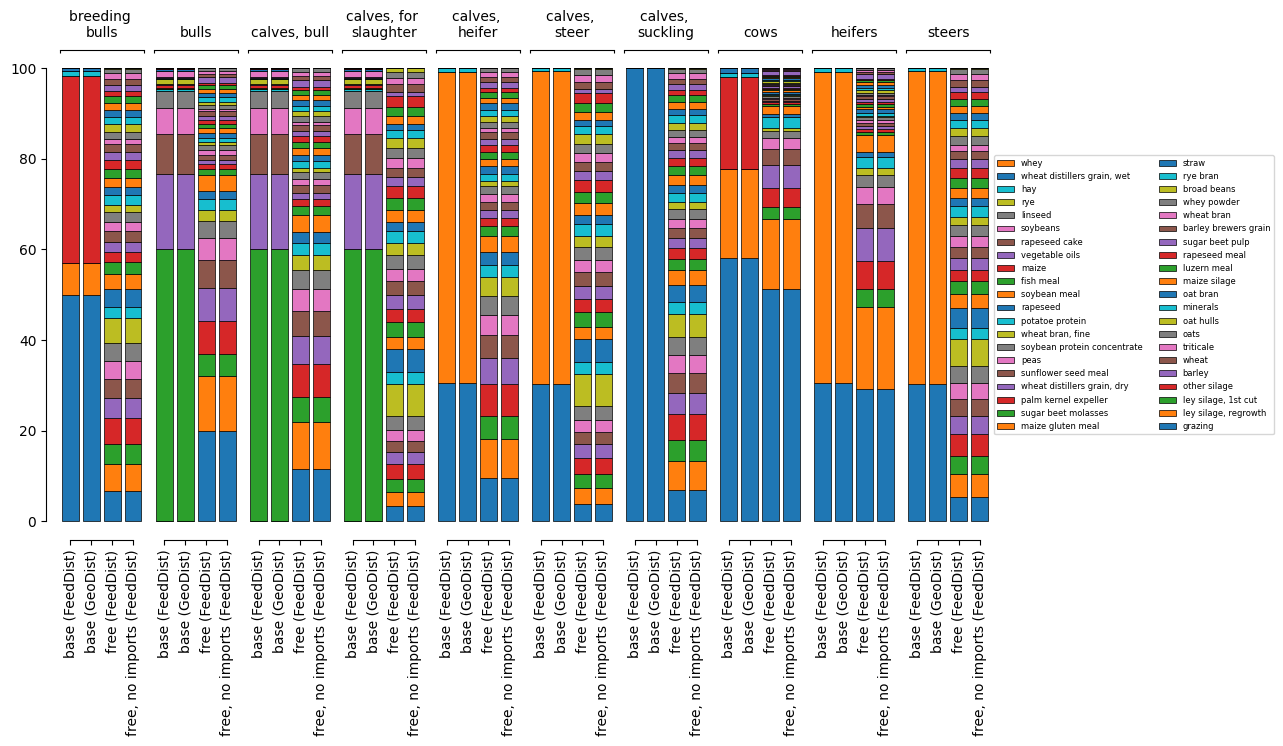

('cattle', 'beef', 'conventional', 'maize based')


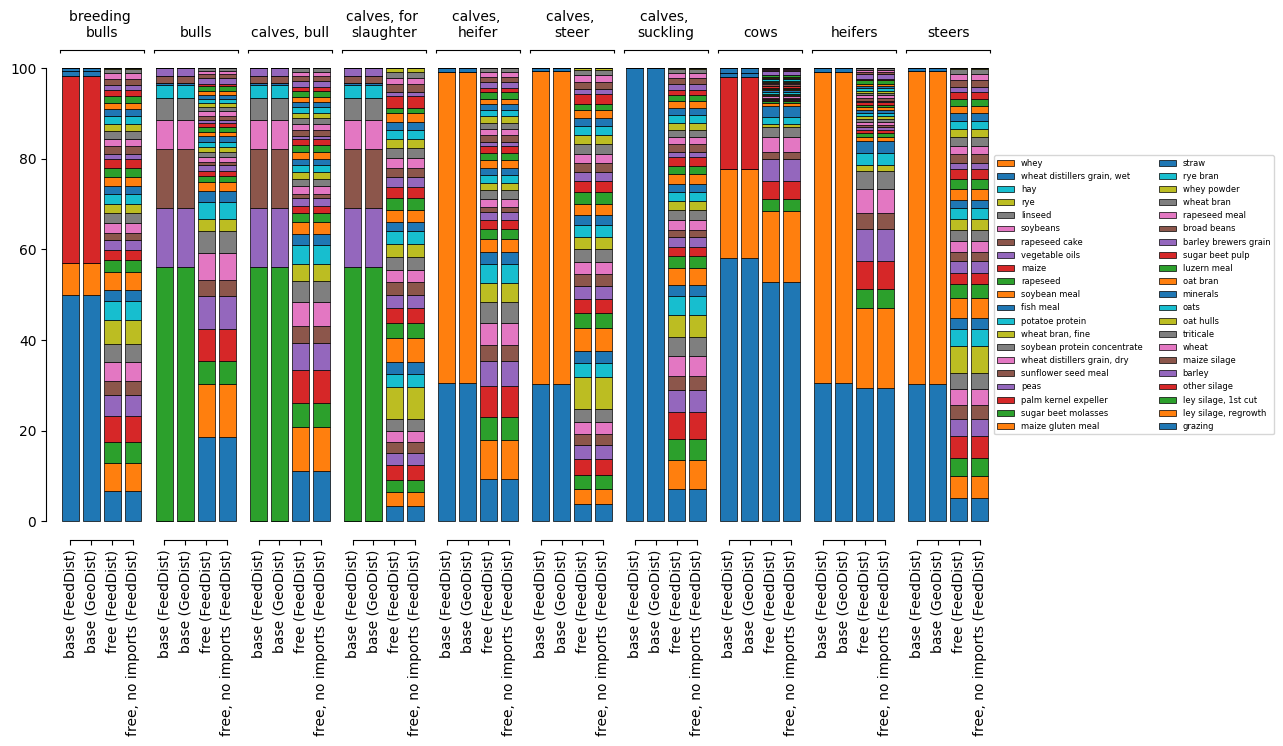

('cattle', 'beef', 'organic', 'ley based')


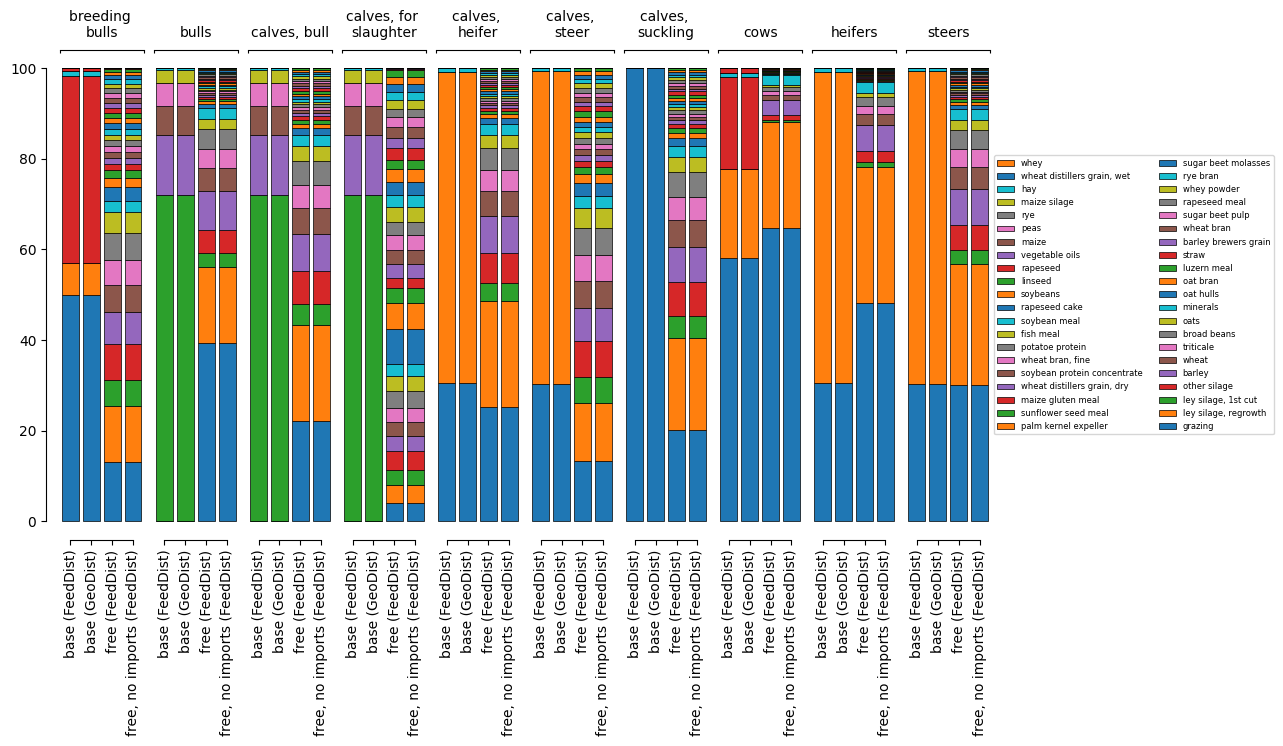

('cattle', 'dairy', 'conventional', 'ley based')


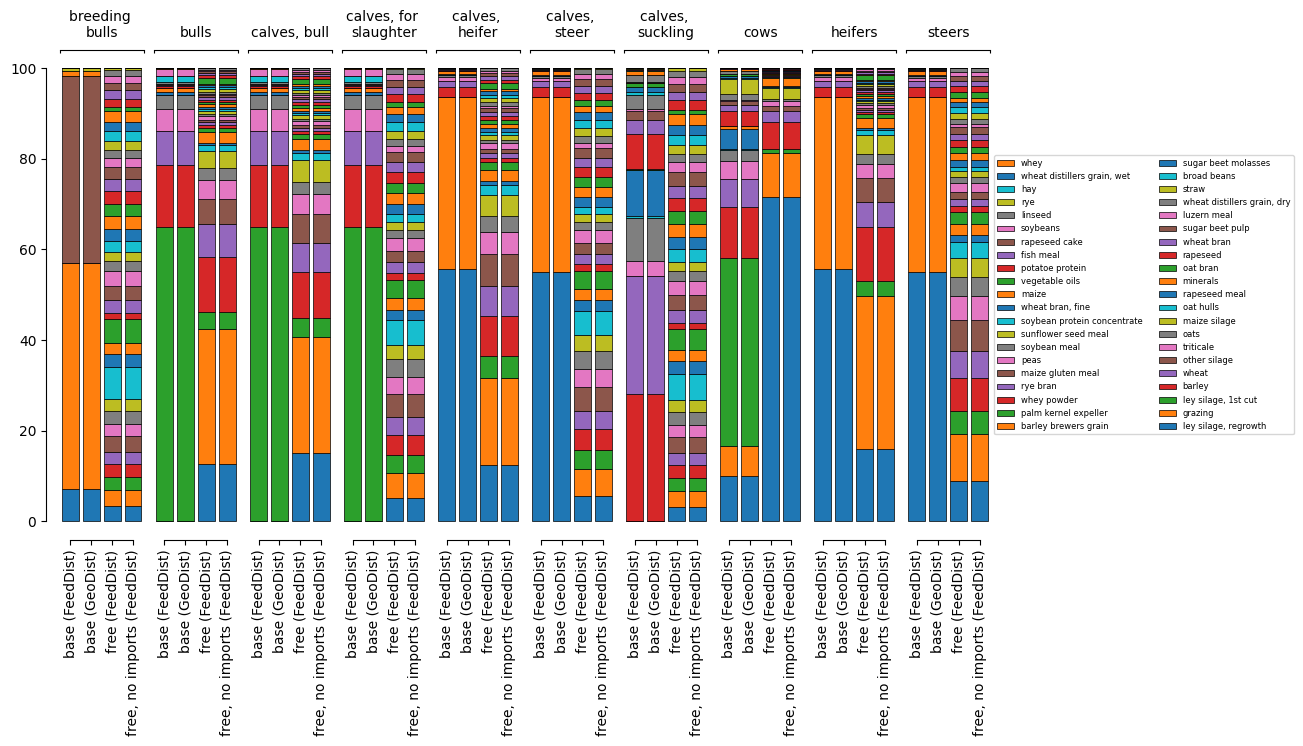

('cattle', 'dairy', 'conventional', 'maize based')


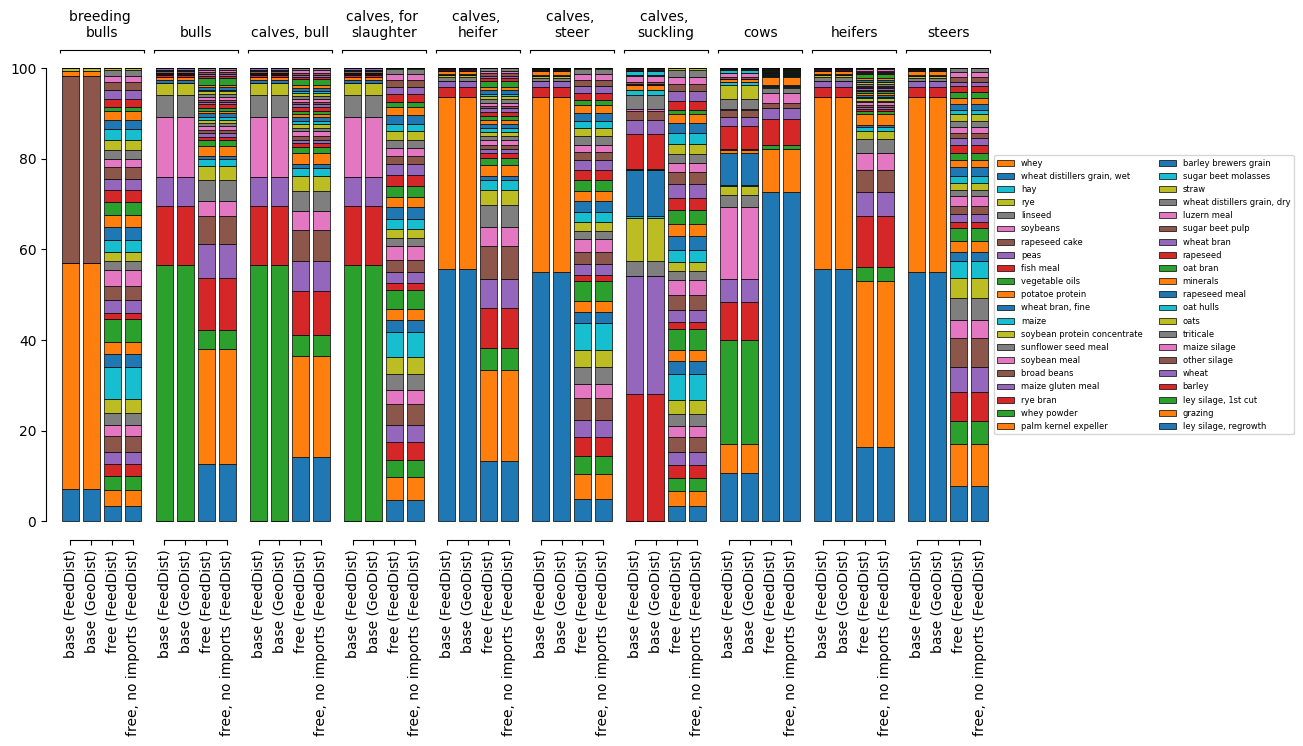

('cattle', 'dairy', 'organic', 'ley based')


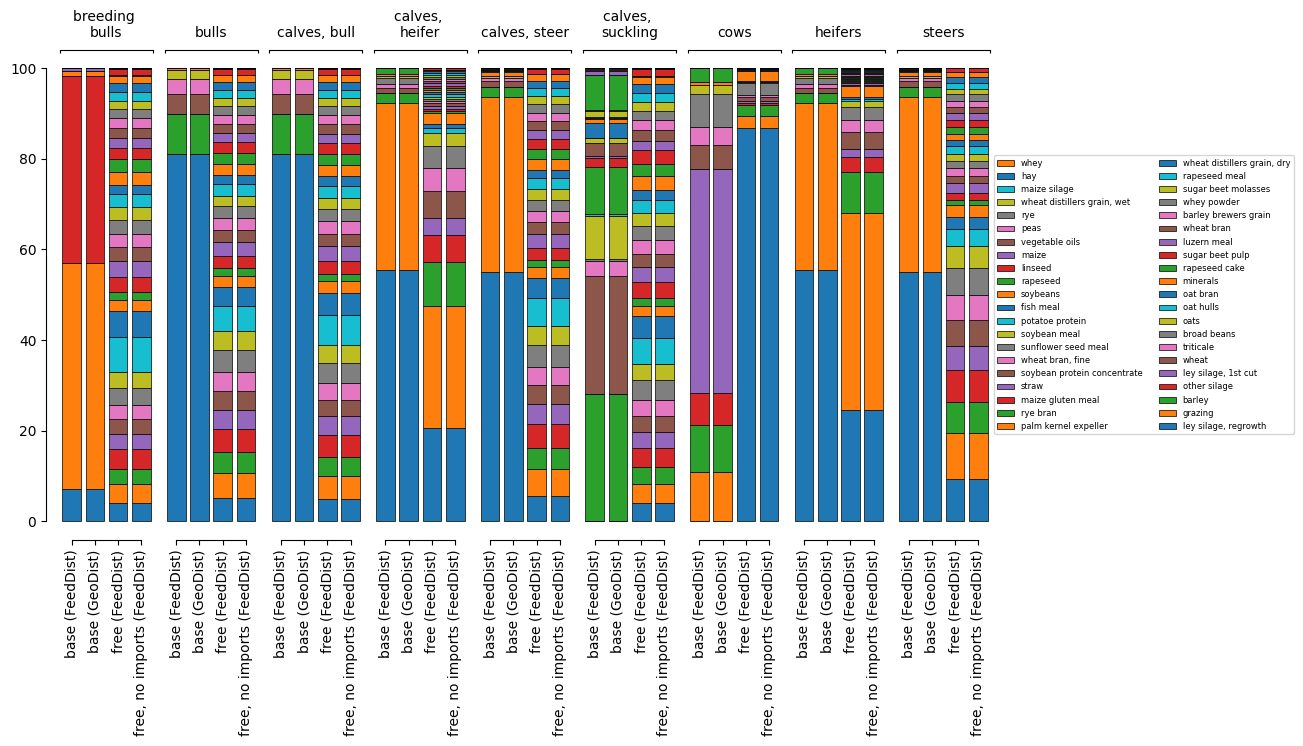

In [9]:
rations = (
    session.get_attr('a','feed.consumption',['species','breed','prod_system','sub_system','animal','feed'])
    .stack(['species','breed','prod_system','sub_system','animal'])
    .fillna(0).div(
        session.get_attr('a','heads',['species','breed','prod_system','sub_system','animal'])
        .stack(['species','breed','prod_system','sub_system','animal']),
        axis = 0
    )
    .stack().droplevel('year').unstack(['scn'])
    .groupby(['species','breed','prod_system','sub_system','animal']).apply(lambda x: x/x.sum()*100)
    .droplevel([0,1,2,3,4])
    .stack().unstack('feed')
)

for idx in rations.loc[['cattle']].index.droplevel(['animal','scn']).unique():
    print(idx)
    fig,ax = plt.subplots(figsize=(12,6))
    cm.plot.bar(
        rations.loc[idx],
        group_levels='animal',
        sort_categories=True,
        ax=ax
    )
    ax.legend(ncol=2, reverse=True, fontsize=6,
              loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

organic


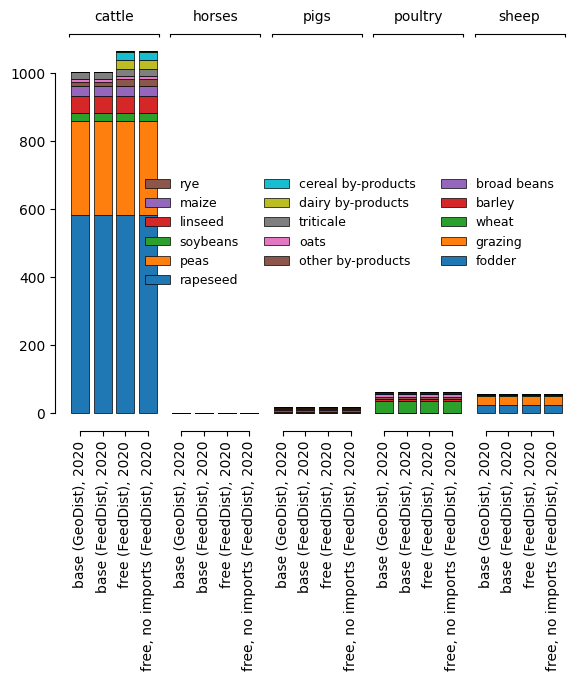

conventional


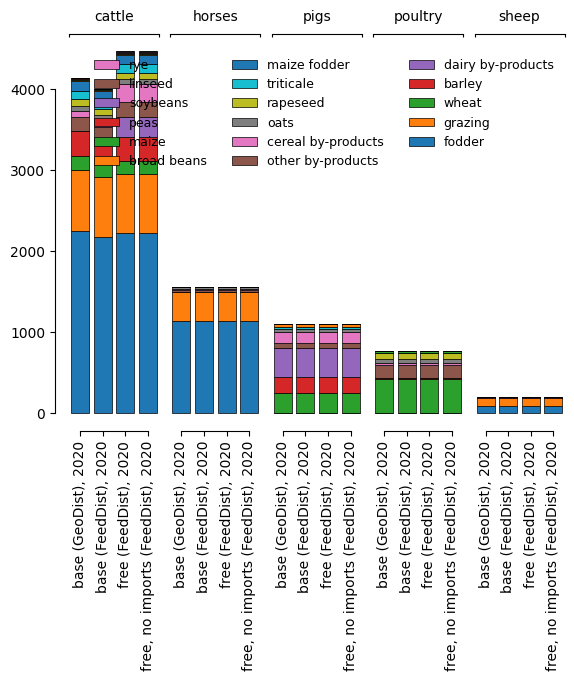

organic


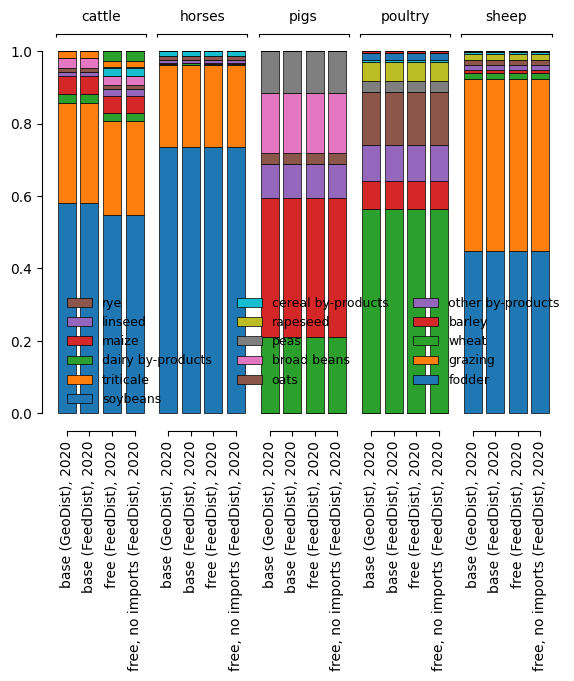

conventional


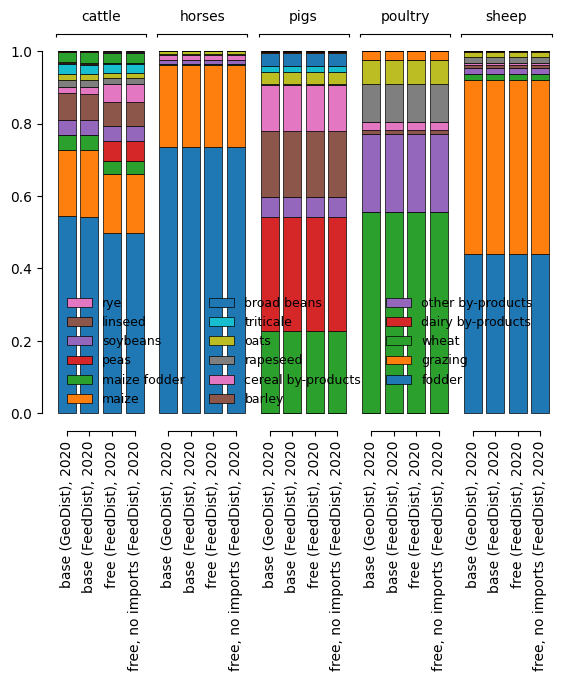

In [16]:
d1 = (
    session.get_attr('a','feed.by_product_demand',{'prod_system':None,'species':None,'by_prod':'by_prod_group'})
    .stack('species')
)
d2 = (
    session.get_attr('a','feed.crop_product_demand',{'prod_system':None,'species':None,'crop_prod':None})
    .stack('species')
)

###########

d = pd.concat([d1,d2], axis=1).fillna(0) / 1_000_000

print('organic')
cm.plot.bar(
    d.loc[:,'organic'],
    group_levels='species',
    sort_categories=True
)
plt.show()
print('conventional')
cm.plot.bar(
    d.loc[:,'conventional'],
    group_levels='species',
    sort_categories=True
)
plt.show()

########

d_frac = d.T.groupby('prod_system').apply(lambda x: x/x.sum()).droplevel(0).T

print('organic')
cm.plot.bar(
    d_frac.loc[:,'organic'],
    group_levels='species',
    sort_categories=True
)
plt.show()
print('conventional')
cm.plot.bar(
    d_frac.loc[:,'conventional'],
    group_levels='species',
    sort_categories=True
)
plt.show()

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

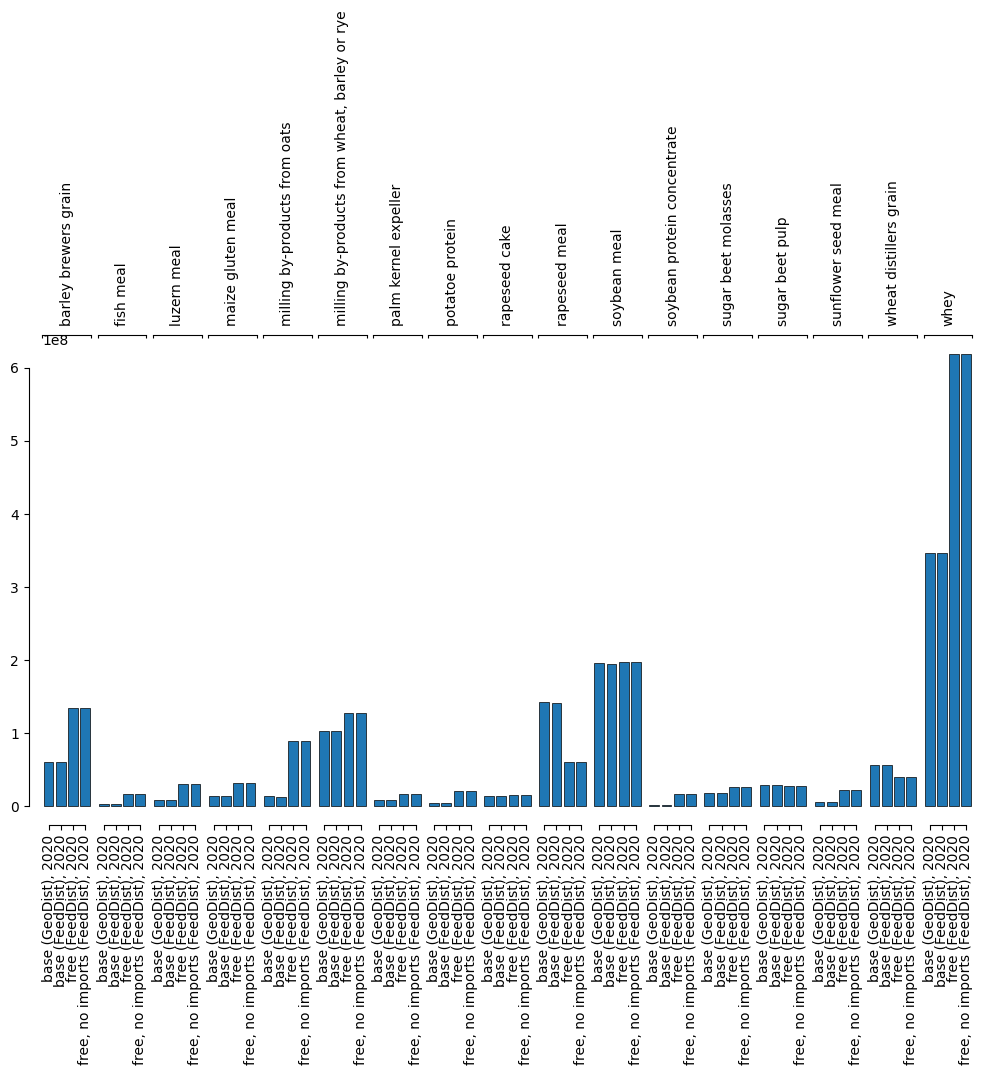

In [17]:
d=session.get_attr('a','feed.by_prod','by_prod').stack()

fig,ax = plt.subplots(figsize=(12,6))
cm.plot.bar(
    d,
    group_levels='by_prod',
    grouplabels_vertical=True,
    ax=ax
)

# Imported crop-/by-products

In [18]:
d = (
    session.get_attr('a','feed.crop_product_demand', ['origin','species','prod_system','crop_prod'])
    .loc[('base (GeoDist)','2020'),'imported']
    # .drop('cattle', level='species')
    .groupby(['prod_system','crop_prod']).sum()
)/1000
d.to_clipboard()
d

prod_system   crop_prod
conventional  linseed        268.709993
              maize        15248.391040
              soybeans      1502.155324
organic       linseed          0.669599
              maize          242.810805
              soybeans      1256.387207
Name: (base (GeoDist), 2020), dtype: float64

In [19]:
d = (
    session.get_attr('a','feed.by_product_demand', ['species','prod_system','by_prod'])
    .loc[('base (GeoDist)','2020')]
    # .drop('cattle', level='species')
    .groupby(['prod_system','by_prod']).sum()
)/1000
d = (
    d.mul(1 - feed_mgmt_geo.par.get('share_domestic', **d.index.to_frame().to_dict('list'))/100)
    .replace({0:np.nan}).dropna(how='all')
)
d.to_clipboard()
d

prod_system   by_prod                                      
conventional  fish meal                                          2618.142569
              luzern meal                                        8515.141042
              maize gluten meal                                 13457.627275
              milling by-products from wheat, barley or rye     20715.192770
              palm kernel expeller                               9317.173344
              rapeseed meal                                     82751.605167
              soybean meal                                     192592.880011
              soybean protein concentrate                        1738.720514
              sunflower seed meal                                5710.175176
organic       fish meal                                            89.137811
              luzern meal                                          30.282574
              maize gluten meal                                   479.972819
              mi

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

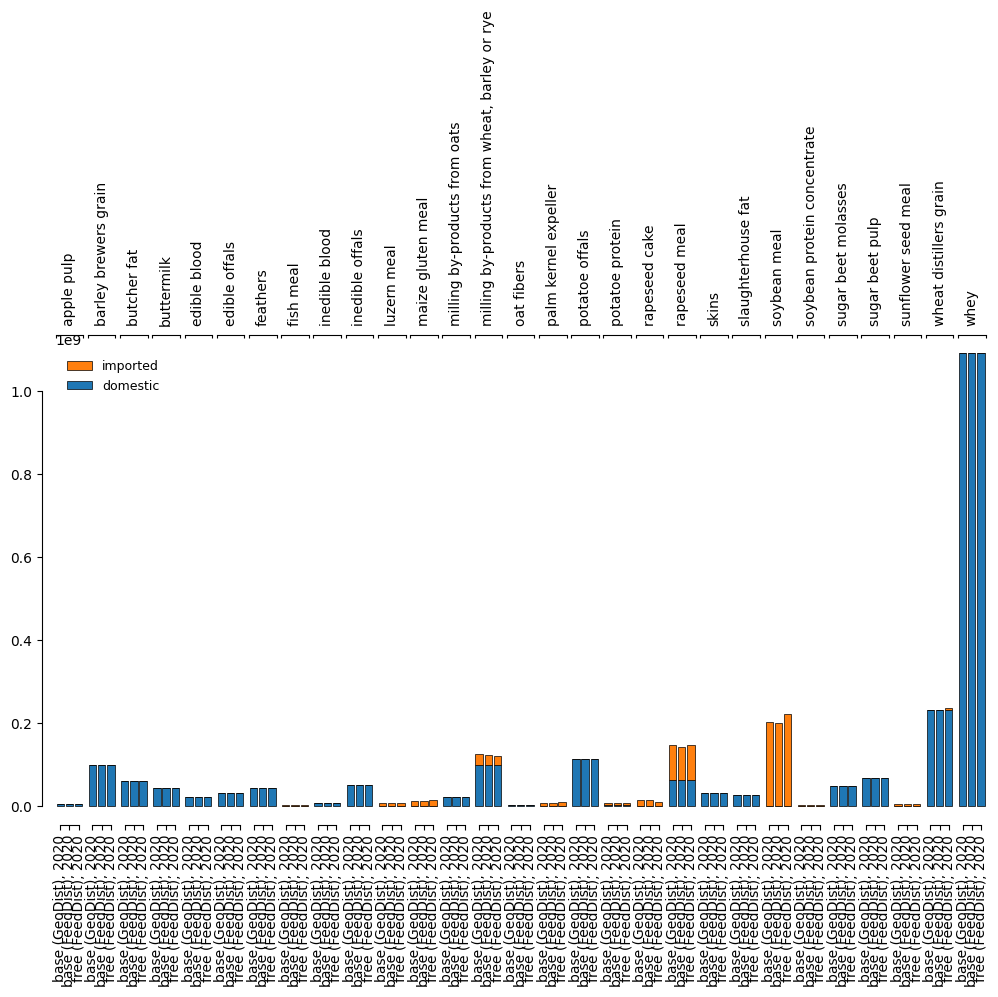

In [67]:
d=session.get_attr('d','by_products',['origin','by_prod']).stack()

fig,ax = plt.subplots(figsize=(12,6))
cm.plot.bar(
    d,
    group_levels='by_prod',
    grouplabels_vertical=True,
    ax=ax
)

(<Axes: >, [<Axes: label='inset_axes'>])

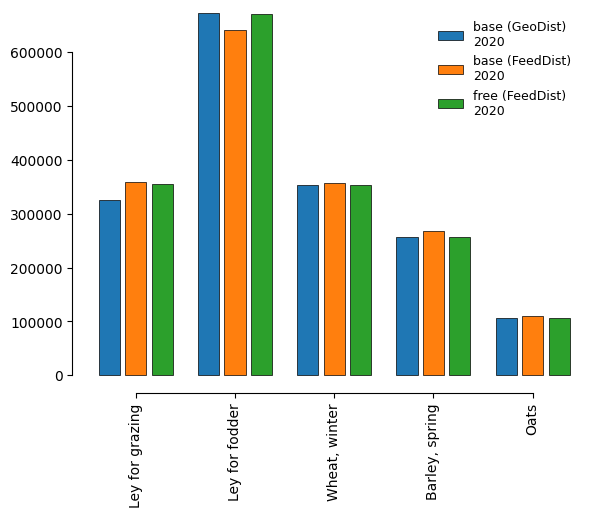

In [77]:
cm.plot.bar(
    session.get_attr('c','area','crop').loc[:,['Ley for grazing','Ley for fodder','Wheat, winter', 'Barley, spring', 'Oats']].T,
    stacked=False
)

In [10]:
pd.concat([
    session.get_attr('c','area','crop').loc[:,'Ley for grazing'],
    session.get_attr('r','x0_crops','crop').loc[:,'Ley for grazing']
])

scn        year
base_feed  2020    351711.146957
base_geo   2020    309243.856482
base_feed  2020    243941.736682
base_geo   2020    243941.736682
Name: Ley for grazing, dtype: float64

In [11]:
pd.concat([
    session.get_attr('c','area','crop').loc[:,'Semi-natural pastures'],
    session.get_attr('r','x0_crops','crop').loc[:,'Semi-natural pastures']
])

scn        year
base_feed  2020    454815.849248
base_geo   2020    373425.650649
base_feed  2020    445155.134909
base_geo   2020    370156.346072
Name: Semi-natural pastures, dtype: float64

In [12]:
rations#.loc[('cattle','dairy','cows')]

feed                                                               grazing  \
species breed prod_system  sub_system  animal         scn                    
cattle  beef  conventional ley based   breeding bulls base_feed  53.115209   
                                                      base_geo   50.052482   
                                       bulls          base_feed   0.000000   
                                                      base_geo    0.000000   
                                       calves, bull   base_feed   0.000000   
...                                                                    ...   
sheep   none  organic      winter lamb ewes           base_geo   55.686616   
                                       lambs          base_feed  46.083142   
                                                      base_geo   41.770329   
                                       rams           base_feed  60.075694   
                                                      base_geo   55.686616   

feed                                                             ley silage, regrowth  \
species breed prod_system  sub_system  animal         scn                               
cattle  beef  conventional ley based   breeding bulls base_feed              6.104350   
                                                      base_geo               7.017813   
                                       bulls          base_feed              0.000000   
                                                      base_geo               0.000000   
                                       calves, bull   base_feed              0.000000   
...                                                                               ...   
sheep   none  organic      winter lamb ewes           base_geo              29.113885   
                                       lambs          base_feed             34.151422   
                                                      base_geo              37.161189   
                                       rams           base_feed             26.163337   
                                                      base_geo              29.113885   

feed                                                             minerals  \
species breed prod_system  sub_system  animal         scn                   
cattle  beef  conventional ley based   breeding bulls base_feed  1.108507   
                                                      base_geo   1.065907   
                                       bulls          base_feed  0.655516   
                                                      base_geo   0.594528   
                                       calves, bull   base_feed  0.659406   
...                                                                   ...   
sheep   none  organic      winter lamb ewes           base_geo   0.000000   
                                       lambs          base_feed  0.000000   
                                                      base_geo   0.000000   
                                       rams           base_feed  0.000000   
                                                      base_geo   0.000000   

feed                                                             other silage  \
species breed prod_system  sub_system  animal         scn                       
cattle  beef  conventional ley based   breeding bulls base_feed     39.035705   
                                                      base_geo      41.192418   
                                       bulls          base_feed      0.000000   
                                                      base_geo       0.000000   
                                       calves, bull   base_feed      0.000000   
...                                                                       ...   
sheep   none  organic      winter lamb ewes           base_geo       0.000000   
                                       lambs          base_feed      0.000000   
               

In [13]:
d = session.get_attr('a', 'feed.consumption',['species','feed']).stack('feed').fillna(0)
((d.loc['base_feed'] - d.loc['base_geo'])/d.loc['base_geo'] * 100).fillna(0).style.format(precision=2)

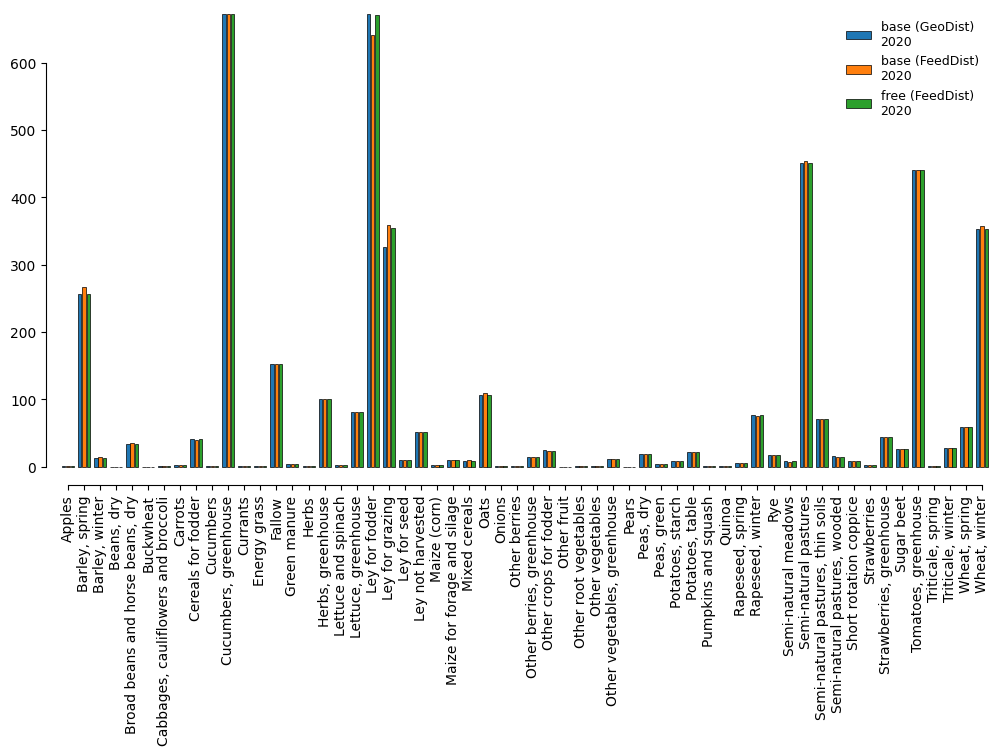

crop
Apples                                  0.02
Barley, spring                          3.82
Barley, winter                          7.68
Beans, dry                             -0.00
Broad beans and horse beans, dry        5.36
Buckwheat                              20.91
Cabbages, cauliflowers and broccoli    -0.06
Carrots                                 0.01
Cereals for fodder                     -4.05
Cucumbers                               0.04
Cucumbers, greenhouse                  -0.00
Currants                                0.01
Energy grass                            0.02
Fallow                                 -0.02
Green manure                            0.30
Herbs                                  -0.05
Herbs, greenhouse                      -0.00
Lettuce and spinach                     0.01
Lettuce, greenhouse                    -0.01
Ley for fodder                         -4.63
Ley for grazing                        10.11
Ley for seed                            0.23
Ley n

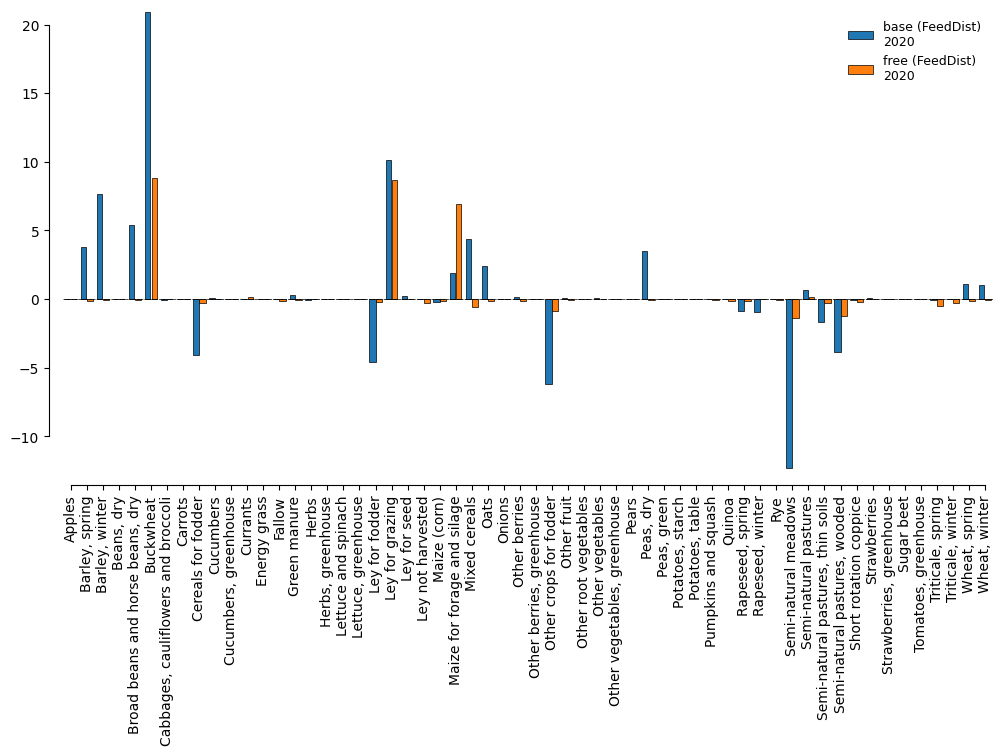

In [17]:
d = session.get_attr('c','area','crop').T / 1_000

fig,ax = plt.subplots(figsize=(12,6))
cm.plot.bar(
    d,
    stacked=False,
    ax=ax
)
plt.show()

fig,ax = plt.subplots(figsize=(12,6))
fig,ax = cm.plot.bar(
    d.iloc[:,1:].sub(d.iloc[:,0], axis=0).div(d.iloc[:,0], axis=0)*100,
    stacked=False,
    ax=ax
)

display(((d.iloc[:,1] - d.iloc[:,0]) / d.iloc[:,0] * 100).round(2))

(<Axes: >, [<Axes: label='inset_axes'>])

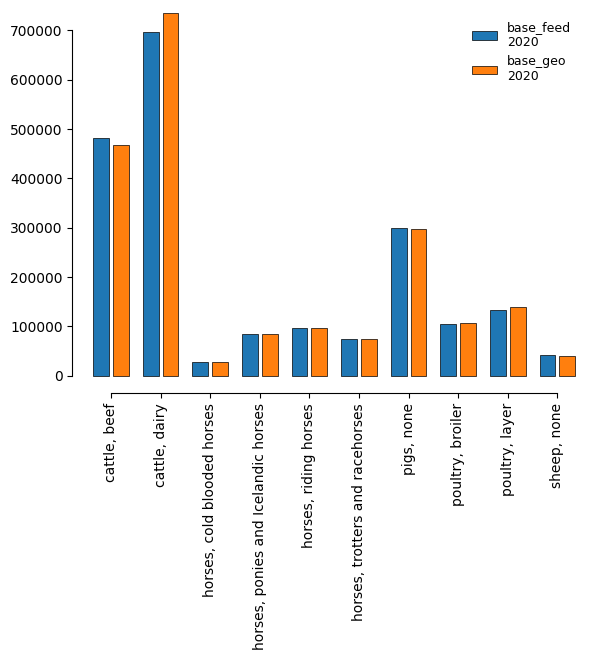

In [15]:
d = cm.impact.get_LSU(session, ['species','breed']).T

cm.plot.bar(
    d,
    stacked=False
)